Two sources:
1. `src/dictionary_collection/mturk/analysis`
2. `src/data_term_gold/processed`

In [1]:
import pandas as pd
import json
data_gold = pd.read_json("/home/jiaruil5/multilingual/multilingual-model-card/src/data_term_gold/processed/arabic.json").rename(columns={"term_reformatted": "word", "term_arabic": "validated_translation"}, inplace=False).drop_duplicates(subset='word', inplace=False)
data_gold['word_lower'] = data_gold['word'].str.lower()
data_6060 = pd.read_csv("/home/jiaruil5/multilingual/multilingual-model-card/src/dictionary_collection/mturk/analysis/annotation_results_6060/Arabic_validated.csv").drop_duplicates(subset='word', inplace=False)
data_mturk = pd.read_csv("/home/jiaruil5/multilingual/multilingual-model-card/src/dictionary_collection/mturk/analysis/annotation_results_crawled/Arabic_validated.csv").drop_duplicates(subset='word', inplace=False)

In [2]:
concat_df = pd.concat([data_6060[['word', 'validated_translation']], data_mturk[['word', 'validated_translation']]], axis=0, ignore_index=True)
concat_df['word_lower'] = concat_df['word'].str.lower()
concat_df

,word,validated_translation,word_lower
0,AI,الذكاء الاصطناعي,ai
1,API,واجهة برمجة التطبيقات,api
2,AQA,AQA,aqa
3,ARENA,أرينا,arena
4,Additionally,بالإضافة إلى ذلك,additionally
...,...,...,...
4985,zero-shot prompting,التحفيز بدون أمثلة,zero-shot prompting
4986,zero-shot reasoning,الاستدلال بدون أمثلة سابقة,zero-shot reasoning
4987,zero-shot setting,إعداد بدون أمثلة,zero-shot setting
4988,zero-shot transfer,النقل الصفري,zero-shot transfer


In [4]:
df_itst = pd.merge(data_gold[['word', 'word_lower', 'validated_translation']], concat_df[['word', 'word_lower', 'validated_translation']], on='word_lower')
df_itst[df_itst['validated_translation_x'] == df_itst['validated_translation_y']].shape[0] / df_itst.shape[0], df_itst[df_itst['validated_translation_x'] == df_itst['validated_translation_y']].shape[0], df_itst.shape[0]

(0.21359223300970873, 22, 103)

In [12]:
def levenshtein_distance(str1, str2):
    # Initialize matrix of distances
    dp = [[0] * (len(str2) + 1) for _ in range(len(str1) + 1)]

    # Base cases
    for i in range(len(str1) + 1):
        dp[i][0] = i
    for j in range(len(str2) + 1):
        dp[0][j] = j

    # Fill the matrix
    for i in range(1, len(str1) + 1):
        for j in range(1, len(str2) + 1):
            if str1[i - 1] == str2[j - 1]:
                dp[i][j] = dp[i - 1][j - 1]  # No operation needed
            else:
                dp[i][j] = min(dp[i - 1][j] + 1,      # Deletion
                               dp[i][j - 1] + 1,      # Insertion
                               dp[i - 1][j - 1] + 1)  # Substitution

    # The distance is in the bottom-right cell
    return dp[-1][-1]

df_itst['levenshtein_dist'] = df_itst.apply(lambda x: levenshtein_distance(x['validated_translation_x'], x['validated_translation_y']), axis=1)

In [17]:
df_itst

,word_x,word_lower,validated_translation_x,word_y,validated_translation_y,levenshtein_dist
0,artificial intelligence,artificial intelligence,ذكاء اصطناعي,Artificial Intelligence,الذكاء الاصطناعي,4
1,machine learning,machine learning,تعُّلم الآلة,Machine Learning,تعلم الآلة,2
2,deep learning,deep learning,تعُّلم عميق,Deep Learning,التعلم العميق,6
3,artificial neural network,artificial neural network,شبكة عصبية اصطناعية,artificial neural network,شبكة عصبية اصطناعية,0
4,natural language processing,natural language processing,معالجة اللغات الطبيعية,Natural Language Processing,معالجة اللغة الطبيعية,2
...,...,...,...,...,...,...
98,Turing test,turing test,اختبار تورينج,Turing Test,اختبار تورينج,0
99,self-training,self-training,تدريب ذاتي,self-training,التدريب الذاتي,4
100,domain adaptation,domain adaptation,تكييف المجال,Domain Adaptation,التكيف المجال,3
101,federated learning,federated learning,تعلم متحد,Federated Learning,التعلم الفيدرالي,10


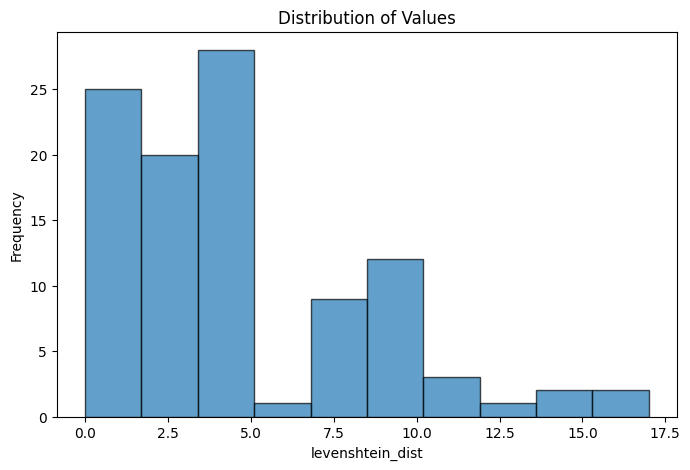

In [15]:
import matplotlib.pyplot as plt
import pandas as pd


# Plot the distribution of the 'values' column
plt.figure(figsize=(8, 5))
plt.hist(df_itst['levenshtein_dist'], bins=10, edgecolor='black', alpha=0.7)
plt.xlabel('levenshtein_dist')
plt.ylabel('Frequency')
plt.title('Distribution of Values')
plt.show()


In [29]:
merged_df = pd.merge(concat_df[['word', 'word_lower', 'validated_translation']], data_gold[['word', 'word_lower', 'validated_translation']], on="word_lower", how='outer', suffixes=('_df2', '_df1'))
merged_df

,word_df2,word_lower,validated_translation_df2,word_df1,validated_translation_df1
0,10-fold cross validation,10-fold cross validation,التحقق المتقاطع بعشر طيات,NaN,NaN
1,1D convolution,1d convolution,الالتفاف أحادي البُعد,NaN,NaN
2,2 norm,2 norm,النورم 2,NaN,NaN
3,2D convolution,2d convolution,الالتفاف ثنائي الأبعاد,NaN,NaN
4,2D image,2d image,صورة ثنائية الأبعاد,NaN,NaN
...,...,...,...,...,...
5059,zero-shot transfer,zero-shot transfer,النقل الصفري,NaN,NaN
5060,zero-shot transfer learning,zero-shot transfer learning,التعلم بالتحويل بدون تدريب,NaN,NaN
5061,Zipf,zipf,زيبف,NaN,NaN
5062,Zipf distribution,zipf distribution,توزيع زيـبف,NaN,NaN


In [30]:
merged_df['validated_translation'] = merged_df['validated_translation_df1'].combine_first(merged_df['validated_translation_df2'])
merged_df['word'] = merged_df['word_df1'].combine_first(merged_df['word_df2'])
merged_df

,word_df2,word_lower,validated_translation_df2,word_df1,validated_translation_df1,validated_translation,word
0,10-fold cross validation,10-fold cross validation,التحقق المتقاطع بعشر طيات,NaN,NaN,التحقق المتقاطع بعشر طيات,10-fold cross validation
1,1D convolution,1d convolution,الالتفاف أحادي البُعد,NaN,NaN,الالتفاف أحادي البُعد,1D convolution
2,2 norm,2 norm,النورم 2,NaN,NaN,النورم 2,2 norm
3,2D convolution,2d convolution,الالتفاف ثنائي الأبعاد,NaN,NaN,الالتفاف ثنائي الأبعاد,2D convolution
4,2D image,2d image,صورة ثنائية الأبعاد,NaN,NaN,صورة ثنائية الأبعاد,2D image
...,...,...,...,...,...,...,...
5059,zero-shot transfer,zero-shot transfer,النقل الصفري,NaN,NaN,النقل الصفري,zero-shot transfer
5060,zero-shot transfer learning,zero-shot transfer learning,التعلم بالتحويل بدون تدريب,NaN,NaN,التعلم بالتحويل بدون تدريب,zero-shot transfer learning
5061,Zipf,zipf,زيبف,NaN,NaN,زيبف,Zipf
5062,Zipf distribution,zipf distribution,توزيع زيـبف,NaN,NaN,توزيع زيـبف,Zipf distribution


In [31]:
ref_df = pd.read_csv("/home/jiaruil5/multilingual/multilingual-model-card/src/dictionary_collection/mturk/analysis/annotation_final/Chinese.csv")
ref_df['word_lower'] = ref_df['word'].str.lower()

In [32]:
merged_df = merged_df[['word', 'validated_translation']].drop_duplicates(subset='word', inplace=False).sort_values(by='word')
merged_df['word_lower'] = merged_df['word'].str.lower()

merged = merged_df.merge(ref_df[['word', 'word_lower']], on='word_lower', how='left', suffixes=('', '_ref'))

# Update 'word' in merged_df with the 'word' from ref_df where it matches
merged['word'] = merged['word_ref'].combine_first(merged['word'])

# Drop the temporary 'word_ref' column used for merging
merged = merged.drop(columns=['word_ref'])
merged

,word,validated_translation,word_lower
0,10-fold cross validation,التحقق المتقاطع بعشر طيات,10-fold cross validation
1,1D convolution,الالتفاف أحادي البُعد,1d convolution
2,2 norm,النورم 2,2 norm
3,2D convolution,الالتفاف ثنائي الأبعاد,2d convolution
4,2D image,صورة ثنائية الأبعاد,2d image
...,...,...,...
5066,zero-shot prompting,التحفيز بدون أمثلة,zero-shot prompting
5067,zero-shot reasoning,الاستدلال بدون أمثلة سابقة,zero-shot reasoning
5068,zero-shot setting,إعداد بدون أمثلة,zero-shot setting
5069,zero-shot transfer,النقل الصفري,zero-shot transfer


In [33]:
merged = merged.drop_duplicates(subset='word_lower', inplace=False)[['word', 'validated_translation']].sort_values(by='word')
merged.to_csv("/home/jiaruil5/multilingual/multilingual-model-card/src/dictionary_collection/mturk/analysis/annotation_final/Arabic.csv")